# Economic charting with `ggplot2` in R

In [10]:
# Load necessary libraries
suppressPackageStartupMessages(library(ggplot2))
suppressPackageStartupMessages(library(dplyr))
suppressPackageStartupMessages(library(tidyr))
suppressPackageStartupMessages(library(magrittr))
suppressPackageStartupMessages(library(lubridate))
suppressPackageStartupMessages(library(stringr))
suppressPackageStartupMessages(library(gridExtra))
suppressPackageStartupMessages(library(zoo))

In [11]:
# Set plot dimensions to 3.9*2 x 3.2 inches
options(repr.plot.width = 3.9, repr.plot.height = 3.2)  # in inches

# Stacked Bar Chart
I will plot U.S. steel imports in billions of dollars using the Census Bureau's API via the `censusapi` library. The documentation for the library can be found [here](https://cran.r-project.org/web/packages/censusapi/censusapi.pdf) and the documentation for the Census' API can be found [here](https://www.census.gov/foreign-trade/reference/guides/Guide_to_International_Trade_Datasets.pdf).

In [12]:
# install.packages("censusapi")
suppressPackageStartupMessages(library(censusapi))

Store personal Census API key in '.Renviron' file. This function checks if the key is stored correctly.

In [13]:
censusapi::has_api_key()

[1] TRUE

Example code taken from `censusapi` examples [here](https://www.hrecht.com/censusapi/articles/example-list.html#international-trade) to check proper functioning of the library.

In [14]:
poverty_rate <- censusapi::getCensus(
    name = "timeseries/poverty/saipe",
    vars = c("NAME", "SAEPOVRTALL_PT"),
    region = "county:037",
    regionin = "state:06",
    time = "from 2010")

poverty_rate

time,state,county,NAME,SAEPOVRTALL_PT
<int>,<chr>,<chr>,<chr>,<dbl>
2010,06,037,Los Angeles County,17.6
2011,06,037,Los Angeles County,18.4
2012,06,037,Los Angeles County,19.1
2013,06,037,Los Angeles County,19.0
2014,06,037,Los Angeles County,18.7
2015,06,037,Los Angeles County,16.7
2016,06,037,Los Angeles County,16.3
2017,06,037,Los Angeles County,14.9
2018,06,037,Los Angeles County,14.2


Check metadata in import data provided by Census Bureau.

In [15]:
# meta_data <- censusapi::listCensusMetadata(name="timeseries/intltrade/imports/hs", type="variables")
# meta_data[,c(1,2)]

Attempt querry on import data provided by Census Bureau.

In [16]:
imports <- censusapi::getCensus(
    name = "timeseries/intltrade/imports/enduse",
    vars = c("CTY_CODE", "CTY_NAME", "GEN_VAL_MO", "CON_VAL_MO"),
    time = "2024-01")
head(imports)

,time,CTY_CODE,CTY_NAME,GEN_VAL_MO,CON_VAL_MO
,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,2024-01,-,TOTAL FOR ALL COUNTRIES,253692671061,254282909564
2,2024-01,0003,EUROPEAN UNION,46462552767,46186075157
3,2024-01,0014,PACIFIC RIM COUNTRIES,79475175773,79024298812
4,2024-01,0017,CAFTA-DR,2476381523,2471197017
5,2024-01,0020,USMCA (NAFTA),71358714212,71239384038
6,2024-01,0021,TWENTY LATIN AMERICAN REPUBLICS,50033637626,50374060112


Filter for iron and steel imports as tracked by HS code 72. Remove supranational entities.

In [17]:
steel_imports <- censusapi::getCensus(
    name = "timeseries/intltrade/imports/hs",
    vars = c("I_COMMODITY_SDESC", "CTY_CODE","CTY_NAME", "GEN_VAL_MO", "YEAR"),
    SUMMARY_LVL = "DET",
    I_COMMODITY = "72",
    time = "from 2015-01"
    )
head(steel_imports)

,time,I_COMMODITY_SDESC,CTY_CODE,CTY_NAME,GEN_VAL_MO,YEAR,SUMMARY_LVL,I_COMMODITY
,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<chr>,<int>
1,2015-01,IRON AND STEEL,5200,UNITED ARAB EMIRATES,758999,2015,DET,72
2,2015-02,IRON AND STEEL,5200,UNITED ARAB EMIRATES,5122822,2015,DET,72
3,2015-03,IRON AND STEEL,5200,UNITED ARAB EMIRATES,1517264,2015,DET,72
4,2015-04,IRON AND STEEL,5200,UNITED ARAB EMIRATES,6115353,2015,DET,72
5,2015-05,IRON AND STEEL,5200,UNITED ARAB EMIRATES,845293,2015,DET,72
6,2015-06,IRON AND STEEL,5200,UNITED ARAB EMIRATES,924622,2015,DET,72


Identify top 6 importing countries versus rest of world. Aggregate by month-country pair and year-country pair in billions of dollars

In [18]:
top_6 <- steel_imports %>% 
filter(CTY_NAME != "TOTAL FOR ALL COUNTRIES") %>%
mutate(country = ifelse(CTY_NAME %in% c("CANADA", "MEXICO", "BRAZIL", "JAPAN", "GERMANY"), CTY_NAME, "REST OF WORLD")) %>%
group_by(country, time) %>%
reframe(total_imports = sum(as.numeric(GEN_VAL_MO))) %>%
mutate(date=as.yearmon(time))
# top_6

top_6_yr <- top_6 %>% 
mutate(year = year(date)) %>%
group_by(country, year) %>%
reframe(total_imports = sum(total_imports)/1000000000)  # in billions
# top_6_yr

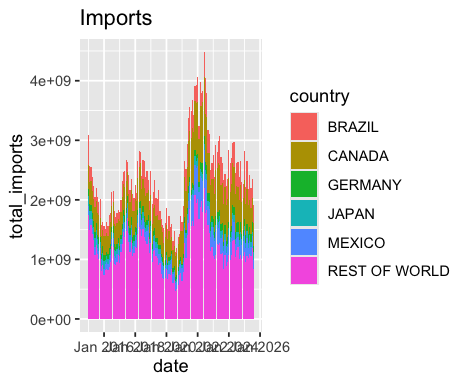

In [19]:
top_6 %>% ggplot(aes(x=date, y=total_imports, fill=country)) + geom_bar(position="stack", stat="identity") + labs(title="Imports")

Group the data into years instead of months

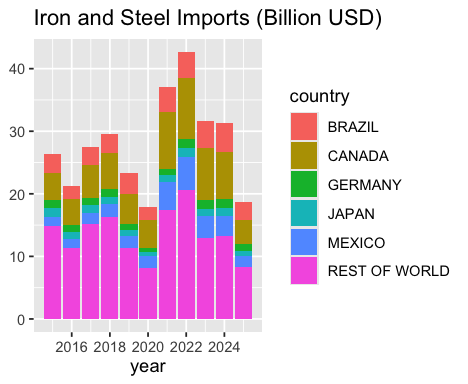

In [20]:
top_6_yr %>% ggplot(aes(x=year, y=total_imports, fill=country)) + 
geom_bar(position="stack", stat="identity") + 
labs(title="Iron and Steel Imports (Billion USD)", y=NULL)

Cleaned-up chart for total imports of iron and steel into the U.S. from top 5 countries and rest of world.

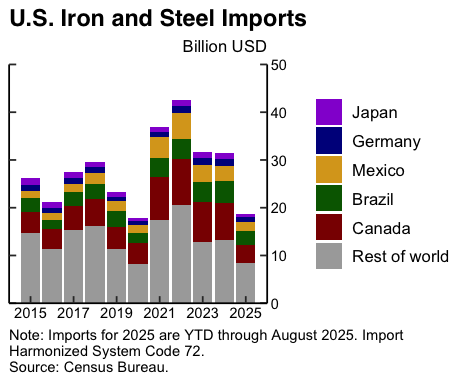

In [26]:
steel <- top_6_yr %>%
  mutate(country = str_to_sentence(country)) %>%
  ggplot(aes(
    x=year,
    y=total_imports,
    fill=factor(country, levels = c("Japan", "Germany", "Mexico", "Brazil", "Canada", "Rest of world")))
    ) + 
  geom_bar(position="stack", stat="identity") +
  scale_x_continuous(breaks = seq(2011, 2025, by = 2)) +
  scale_y_continuous(
    position = "right",
    sec.axis = dup_axis(labels = NULL),
    breaks = seq(0, 50, by = 10),
    limits = c(0, 50),
    expand = c(0, 0)
    ) +
  scale_fill_manual(
    NULL,
    values = c(
      "Canada" = "darkred",
      "Mexico" = "goldenrod",
      "Brazil" = "darkgreen",
      "Japan" = "darkviolet",
      "Germany" = "darkblue",
      "Rest of world" = "darkgrey"
    )
  ) +
  xlab(NULL) + ylab(NULL) +
  labs(
    title = "U.S. Iron and Steel Imports", 
    subtitle = "Billion USD", 
    caption = paste0(
      "Note: Imports for 2025 are YTD through ",format(max(top_6$date), "%B %Y"),". Import",
      "\nHarmonized System Code 72.",
      "\nSource: Census Bureau."
      )
    ) +
  theme_classic() +
  theme(
      plot.title = element_text(family = "Helvetica", face = "bold", size = 14),
      plot.subtitle = element_text(hjust = 1, size = 10),
      axis.text = element_text(color = "black"),
      axis.ticks.length = unit(-0.15, "cm"),
      plot.caption = element_text(hjust = 0),
      legend.text = element_text(size = 10)
      )

steel

ggsave("../plots/steel.png", plot = steel, width = 3.9*1.25, height = 3.2+(0.13*3), units = "in", dpi = 300)